#  Ziel:
Mit wenig Rechenleistung/Aufwand vielversprechende Reinforcement Learning (folgend RL) Ansätze identifizieren. Diese werden in Isaac Sim umgesetzt. Damit wird rechenintensives Trial an Error in Isaac Sim umgangen.


## Ansätze aus Brainstorming:

### Ideen für die Verwendung von Bildinformationen:

-Gerichtetes Birdseye - Dauerhafte Autofeste-Vogelperspektive (zuschnitt)

-Gesamtes Bild - Weltfeste Kamera, gesamte Strecke im Bild

-Vorverarbeitung des Bilds, um Geschwindigkeit, Position(Pixelkoordinaten) und Ausrichtung zu extrahieren

### Ideen für die KI-Inputs:

-1 Bild

-2 oder 3 Bilder

-Die letzten Outputs der KI (Geschwindigkeitsbefehl entspricht nährungsweise der Geschwindigkeit des Autos)

-Parameter des Fahrzeugs, von Computervision (folgend CV) extrahiert


## Umgebung erzeugen

Rennstrecke als Bild initialisieren, anschließend das Auto initialisieren

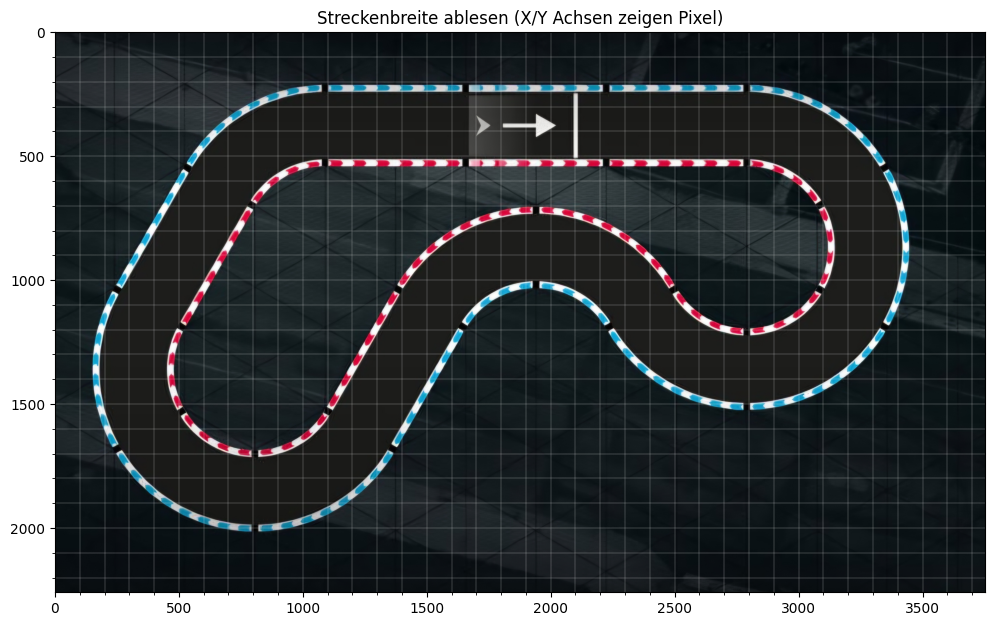

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Lade das Streckenbild
img = mpimg.imread('data/strecke.jpg')

# Zeige das Bild groß an
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.title("Streckenbreite ablesen (X/Y Achsen zeigen Pixel)")
plt.grid(color='w', linestyle='-', linewidth=0.3, alpha=0.5, which='both')
plt.minorticks_on()
plt.show()

# Notiz für dich:
# Lies die Pixelzahl an der Innen- und Außenkante der Strecke ab.
# Strecke in Pixel = Außenkante - Innenkante
# Skalierung = Strecke in Pixel / 0.25 (da die echte Breite 0.25m ist)

## Das Spiel mit PyGame auf Basis von carrera_2d_env.py erstellen

In [6]:
import pygame
import numpy as np
from src.envs.carrera_2d_env import Carrera2DEnv

# 1. Environment initialisieren
# (Pfade anpassen, falls nötig)
env = Carrera2DEnv(track_image_path="data/strecke.jpg", 
                   car_image_path="data/carrera_car.jpeg")

# Startzustand abrufen
obs, info = env.reset()

# 2. Pygame Setup für die Notebook-Integration
pygame.init()
clock = pygame.time.Clock()
running = True

print("🎮 WASD Steuerung aktiv. Klicke auf das Pygame-Fenster!")
print("Drücke ESC oder schließe das Fenster, um zu beenden.")

# 3. Der Main Loop
while running:
    # A) Fenster-Events abfangen (sonst stürzt das Fenster ab)
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False
        elif event.type == pygame.KEYDOWN:
            if event.key == pygame.K_ESCAPE:
                running = False

    # B) WASD Tasten abfragen
    keys = pygame.key.get_pressed()
    
    # Gas (W = 1.0, Leerlauf = 0.0)
    gas = 1.0 if keys[pygame.K_w] else 0.0
    
    # Bremse (S = 1.0, Leerlauf = 0.0)
    brake = 1.0 if keys[pygame.K_s] else 0.0
    
    # Lenkung (A = links (-1.0), D = rechts (1.0))
    steer = 0.0
    if keys[pygame.K_a]:
        steer = -1.0
    elif keys[pygame.K_d]:
        steer = 1.0

    # Action-Vektor für das Environment erstellen
    action = np.array([gas, brake, steer], dtype=np.float32)

    # C) Physik-Schritt ausführen
    # Hier feuert deine Einspurmodell-Logik
    obs, reward, terminated, truncated, info = env.step(action)

    # D) Bild zeichnen
    env.render()

    # E) FPS limitieren (entspricht Delta t von ~0.033s)
    clock.tick(30)

# 4. Aufräumen, wenn die Schleife beendet wird
env.close()
pygame.quit()
print("🛑 Simulation beendet.")

AttributeError: 'Carrera2DEnv' object has no attribute 'reset'